In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [3]:
data_path = Path("./data/kurbanov_fraud_data.csv")
df = pd.read_csv(data_path, index_col=0)

# Data Governance

In [7]:
df.head()

,transaction_id,timestamp,merchant_category,merchant_type,amount,currency,country,city,city_size,card_type,...,distance_from_home,high_risk_merchant,transaction_hour,weekend_transaction,num_transac_last_hour,total_amount_last_hour,unique_merchants_last_hour,unique_countries_last_hour,max_single_amount_last_hour,is_fraud
0,TX_a7f9ded2,2024-10-17 15:05:39.603135+00:00,Gas,major,441.96,USD,USA,New York,large,Basic Debit,...,1,False,15,False,482.0,1.402270e+07,102.0,12.0,8.366848e+05,False
1,TX_7eef9759,2024-10-12 03:06:53.888974+00:00,Entertainment,gaming,19.11,BRL,Brazil,Unknown City,medium,Platinum Credit,...,1,True,3,True,424.0,1.554976e+07,98.0,12.0,1.563318e+06,True
2,TX_54b9e43b,2024-10-24 16:47:28.341902+00:00,Gas,major,417.04,USD,USA,Philadelphia,medium,Basic Debit,...,0,False,16,False,193.0,3.494386e+06,86.0,12.0,6.687443e+05,False
3,TX_50a0d972,2024-10-04 09:53:28.036775+00:00,Retail,online,669.02,SGD,Singapore,Unknown City,medium,Basic Debit,...,0,False,9,False,1228.0,3.559787e+07,105.0,12.0,2.046594e+06,False
4,TX_f59953ce,2024-10-11 22:14:35.991700+00:00,Gas,local,730115.44,NGN,Nigeria,Unknown City,medium,Basic Credit,...,1,False,22,False,88.0,4.119283e+06,58.0,9.0,1.972915e+06,True


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   transaction_id               6000 non-null   str    
 1   timestamp                    6000 non-null   str    
 2   merchant_category            6000 non-null   str    
 3   merchant_type                6000 non-null   str    
 4   amount                       6000 non-null   float64
 5   currency                     6000 non-null   str    
 6   country                      6000 non-null   str    
 7   city                         6000 non-null   str    
 8   city_size                    6000 non-null   str    
 9   card_type                    6000 non-null   str    
 10  card_present                 6000 non-null   bool   
 11  device                       6000 non-null   str    
 12  channel                      6000 non-null   str    
 13  distance_from_home           

In [25]:
EXPECTED_SCHEMA = {
    "transaction_id": "str",
    "timestamp": "str",
    "merchant_category": "str",
    "merchant_type": "str",
    "amount": "float64",
    "currency": "str",
    "country": "str",
    "city": "str",
    "city_size": "str",
    "card_type": "str",
    "card_present": "bool",
    "device": "str",
    "channel": "str",
    "distance_from_home": "int64",
    "high_risk_merchant": "bool",
    "transaction_hour": "int64",
    "weekend_transaction": "bool",
    "num_transac_last_hour": "float64",
    "total_amount_last_hour": "float64",
    "unique_merchants_last_hour": "float64",
    "unique_countries_last_hour": "float64",
    "max_single_amount_last_hour": "float64",
    "is_fraud": "bool",
}

VALID_RANGES = {
    "amount": (0, 10_000_000),
    "transaction_hour": (0, 23),
    "unique_countries_last_hour": (0, 200),
}

VALID_CATEGORIES = {
    "currency": ["USD", "EUR", "GBP", "CAD", "AUD", "JPY", "BRL", "RUB", "NGN", "SGD", "MXN"],
    "channel": ["web", "mobile", "pos", "atm"],
    "city_size": ["small", "medium", "large"],
}


def check_data_quality(df: pd.DataFrame) -> dict:
    report = {
        "total_rows": len(df),
        "checks": {},
    }

    schema_errors = []
    for col, expected_dtype in EXPECTED_SCHEMA.items():
        if col not in df.columns:
            schema_errors.append(f"Missing column: {col}")
        elif str(df[col].dtype) != expected_dtype:
            schema_errors.append(f"{col}: expected {expected_dtype}, got {df[col].dtype}")
    report["checks"]["schema"] = {
        "passed": len(schema_errors) == 0,
        "errors": schema_errors,
    }

    null_counts = df.isnull().sum()
    null_cols = null_counts[null_counts > 0].to_dict()
    report["checks"]["nulls"] = {
        "passed": len(null_cols) == 0,
        "null_counts": null_cols,
        "total_nulls": int(null_counts.sum()),
    }

    dup_count = df.duplicated(subset=["transaction_id"]).sum() if "transaction_id" in df.columns else 0
    report["checks"]["duplicates"] = {
        "passed": dup_count == 0,
        "duplicate_transaction_ids": int(dup_count),
    }

    range_errors = {}
    for col, (min_val, max_val) in VALID_RANGES.items():
        if col in df.columns:
            out_of_range = ((df[col] < min_val) | (df[col] > max_val)).sum()
            if out_of_range > 0:
                range_errors[col] = int(out_of_range)
    report["checks"]["ranges"] = {
        "passed": len(range_errors) == 0,
        "out_of_range": range_errors,
    }

    category_errors = {}
    for col, valid_values in VALID_CATEGORIES.items():
        if col in df.columns:
            invalid = ~df[col].isin(valid_values)
            if invalid.sum() > 0:
                category_errors[col] = {
                    "invalid_count": int(invalid.sum()),
                    "invalid_values": df.loc[invalid, col].unique().tolist()[:5],
                }
    report["checks"]["categories"] = {
        "passed": len(category_errors) == 0,
        "invalid_categories": category_errors,
    }

    report["overall_passed"] = all(
        check.get("passed", True) for check in report["checks"].values() if isinstance(check, dict) and "passed" in check
    )

    return report


quality_report = check_data_quality(df)
print("=== Data Quality Report ===")
print(f"Total rows: {quality_report['total_rows']}")
print(f"Overall passed: {quality_report['overall_passed']}")
print()
for check_name, check_result in quality_report["checks"].items():
    status = "✓" if check_result.get("passed", True) else "✗"
    print(f"{status} {check_name}: {check_result}")

=== Data Quality Report ===
Total rows: 6000
Overall passed: True

✓ schema: {'passed': True, 'errors': []}
✓ nulls: {'passed': True, 'null_counts': {}, 'total_nulls': 0}
✓ duplicates: {'passed': np.True_, 'duplicate_transaction_ids': 0}
✓ ranges: {'passed': True, 'out_of_range': {}}
✓ categories: {'passed': True, 'invalid_categories': {}}


## Statistical Distribution Profile

In [24]:
SKIP_CATEGORICAL_COLS = {"transaction_id", "timestamp"}


def compute_distribution_profile(df: pd.DataFrame) -> dict:
    profile = {
        "total_rows": len(df),
        "total_columns": len(df.columns),
        "numeric_columns": {},
        "categorical_columns": {},
        "boolean_columns": {},
    }

    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]) and not pd.api.types.is_bool_dtype(df[col]):
            series = df[col].dropna()
            profile["numeric_columns"][col] = {
                "mean": float(series.mean()),
                "std": float(series.std()),
                "min": float(series.min()),
                "max": float(series.max()),
            }

        elif pd.api.types.is_bool_dtype(df[col]):
            series = df[col].dropna()
            true_count = int(series.sum())
            false_count = int(len(series) - true_count)
            profile["boolean_columns"][col] = {
                "true_count": true_count,
                "false_count": false_count,
                "true_ratio": float(true_count / len(series)) if len(series) > 0 else 0,
                "imbalance_ratio": float(max(true_count, false_count) / min(true_count, false_count))
                if min(true_count, false_count) > 0 else float("inf"),
            }

        elif col not in SKIP_CATEGORICAL_COLS:
            series = df[col].dropna()
            value_counts = series.value_counts()
            profile["categorical_columns"][col] = {
                "unique_count": int(series.nunique()),
                "most_frequent": str(value_counts.index[0]) if len(value_counts) > 0 else None,
                "most_frequent_count": int(value_counts.iloc[0]) if len(value_counts) > 0 else 0,
                "least_frequent": str(value_counts.index[-1]) if len(value_counts) > 0 else None,
                "least_frequent_count": int(value_counts.iloc[-1]) if len(value_counts) > 0 else 0,
                "top_5": value_counts.head(5).to_dict(),
            }

    return profile


def print_distribution_summary(profile: dict) -> None:
    print("=== Statistical Distribution Profile ===\n")
    print(f"Dataset: {profile['total_rows']} rows x {profile['total_columns']} columns\n")

    print("NUMERIC COLUMNS:")
    print("-" * 80)
    print(f"{'Column':<30} {'Mean':>12} {'Std':>12} {'Min':>12} {'Max':>12}")
    print("-" * 80)
    for col, stats_dict in profile["numeric_columns"].items():
        print(f"{col:<30} {stats_dict['mean']:>12.2f} {stats_dict['std']:>12.2f} "
              f"{stats_dict['min']:>12.2f} {stats_dict['max']:>12.2f}")
    print()

    print("BOOLEAN COLUMNS:")
    print("-" * 70)
    print(f"{'Column':<30} {'True':>10} {'False':>10} {'True Ratio':>12} {'Imbalance':>10}")
    print("-" * 70)
    for col, stats_dict in profile["boolean_columns"].items():
        imb = f"{stats_dict['imbalance_ratio']:.2f}" if stats_dict['imbalance_ratio'] != float('inf') else "inf"
        print(f"{col:<30} {stats_dict['true_count']:>10} {stats_dict['false_count']:>10} "
              f"{stats_dict['true_ratio']:>12.2%} {imb:>10}")
    print()

    print("CATEGORICAL COLUMNS:")
    print("-" * 60)
    print(f"{'Column':<25} {'Unique':>8} {'Most Frequent':<20}")
    print("-" * 60)
    for col, stats_dict in profile["categorical_columns"].items():
        print(f"{col:<25} {stats_dict['unique_count']:>8} {str(stats_dict['most_frequent']):<20}")


distribution_profile = compute_distribution_profile(df)
print_distribution_summary(distribution_profile)

=== Statistical Distribution Profile ===

Dataset: 6000 rows x 23 columns

NUMERIC COLUMNS:
--------------------------------------------------------------------------------
Column                                 Mean          Std          Min          Max
--------------------------------------------------------------------------------
amount                             75019.00    273411.30         0.03   6253152.62
distance_from_home                     0.55         0.50         0.00         1.00
transaction_hour                      10.96         6.99         0.00        23.00
num_transac_last_hour                414.90       392.29         0.00      3807.00
total_amount_last_hour          19730993.14  34916731.67         1.08 580153660.24
unique_merchants_last_hour            80.21        30.63         0.00       105.00
unique_countries_last_hour            10.64         2.68         0.00        12.00
max_single_amount_last_hour      1735674.94   1394623.91         1.08   6253152.62

# Data processing

In [5]:
df["distance_from_home"] = df["distance_from_home"].astype(bool)
df["transaction_hour"] = df["transaction_hour"].astype(str)
df = df.drop(columns=["transaction_id", "timestamp"])

In [6]:
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"].astype(int)

In [7]:
num_feats = [
    "amount",
    "num_transac_last_hour",
    "total_amount_last_hour",
    "unique_merchants_last_hour",
    "unique_countries_last_hour",
    "max_single_amount_last_hour",
]

bin_feats = [
    "card_present",
    "distance_from_home",
    "high_risk_merchant",
    "high_risk_merchant",
    "weekend_transaction",
]

cat_feats = [
    "merchant_category",
    "merchant_type",
    "currency",
    "country",
    "city",
    "city_size",
    "card_type",
    "device",
    "channel",
    "transaction_hour",
]

In [8]:
preprocessor = ColumnTransformer(
  transformers=[
      ("num", StandardScaler(), num_feats),
      ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats),
  ],
  remainder="passthrough",
)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)
X_train.shape, X_test.shape

((4500, 20), (1500, 20))

# Model

In [18]:
# model = GradientBoostingClassifier(
#     learning_rate=0.1,
#     n_estimators=100,
#     random_state=42,
#     # verbose=1,
# )
model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
)

In [19]:
pipe = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

# train

In [20]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

# metrics

In [21]:
pipe.score(X_test,y_test)

0.9226666666666666

In [22]:
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.92      0.93      0.92       750
           1       0.93      0.91      0.92       750

    accuracy                           0.92      1500
   macro avg       0.92      0.92      0.92      1500
weighted avg       0.92      0.92      0.92      1500

ROC-AUC: 0.9758560000000001


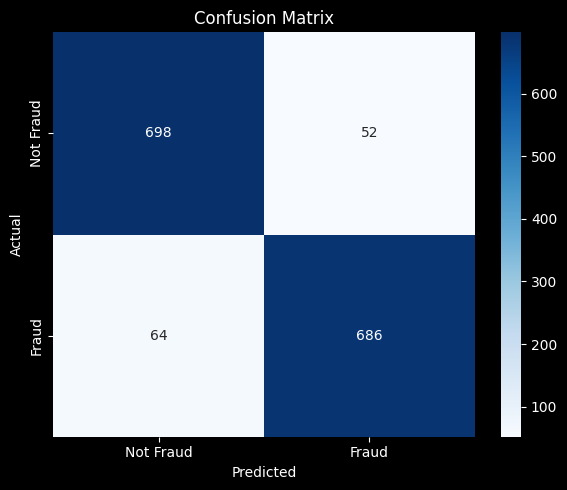

In [46]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Not Fraud", "Fraud"], 
            yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# Feature importance

In [23]:
feature_names = pipe.named_steps["preprocessor"].get_feature_names_out()
feature_names = [name.split("__", 1)[-1] for name in feature_names]

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": pipe.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_df.head(20)

,feature,importance
109,distance_from_home,0.285284
0,amount,0.096542
108,card_present,0.072961
82,channel_pos,0.071383
2,total_amount_last_hour,0.029452
5,max_single_amount_last_hour,0.026257
1,num_transac_last_hour,0.024369
3,unique_merchants_last_hour,0.018914
83,channel_web,0.017491
78,device_NFC Payment,0.014508


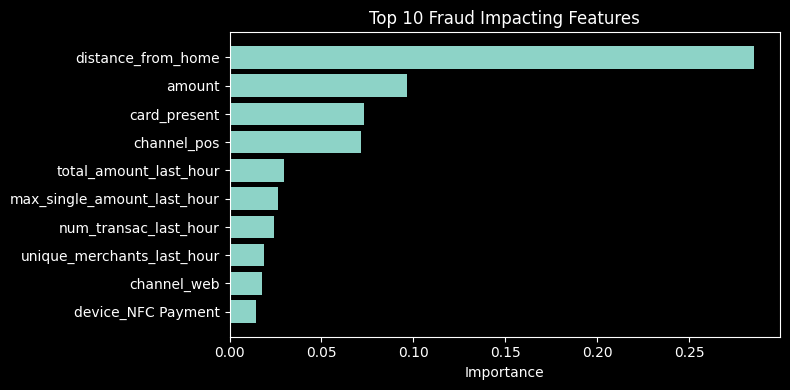

In [30]:
top10 = feature_importance_df.head(10)

plt.figure(figsize=(8, 4))
plt.barh(top10["feature"], top10["importance"])
plt.xlabel("Importance")
plt.title("Top 10 Fraud Impacting Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Analysis

In [31]:
df_eda = pd.read_csv(data_path, index_col=0)

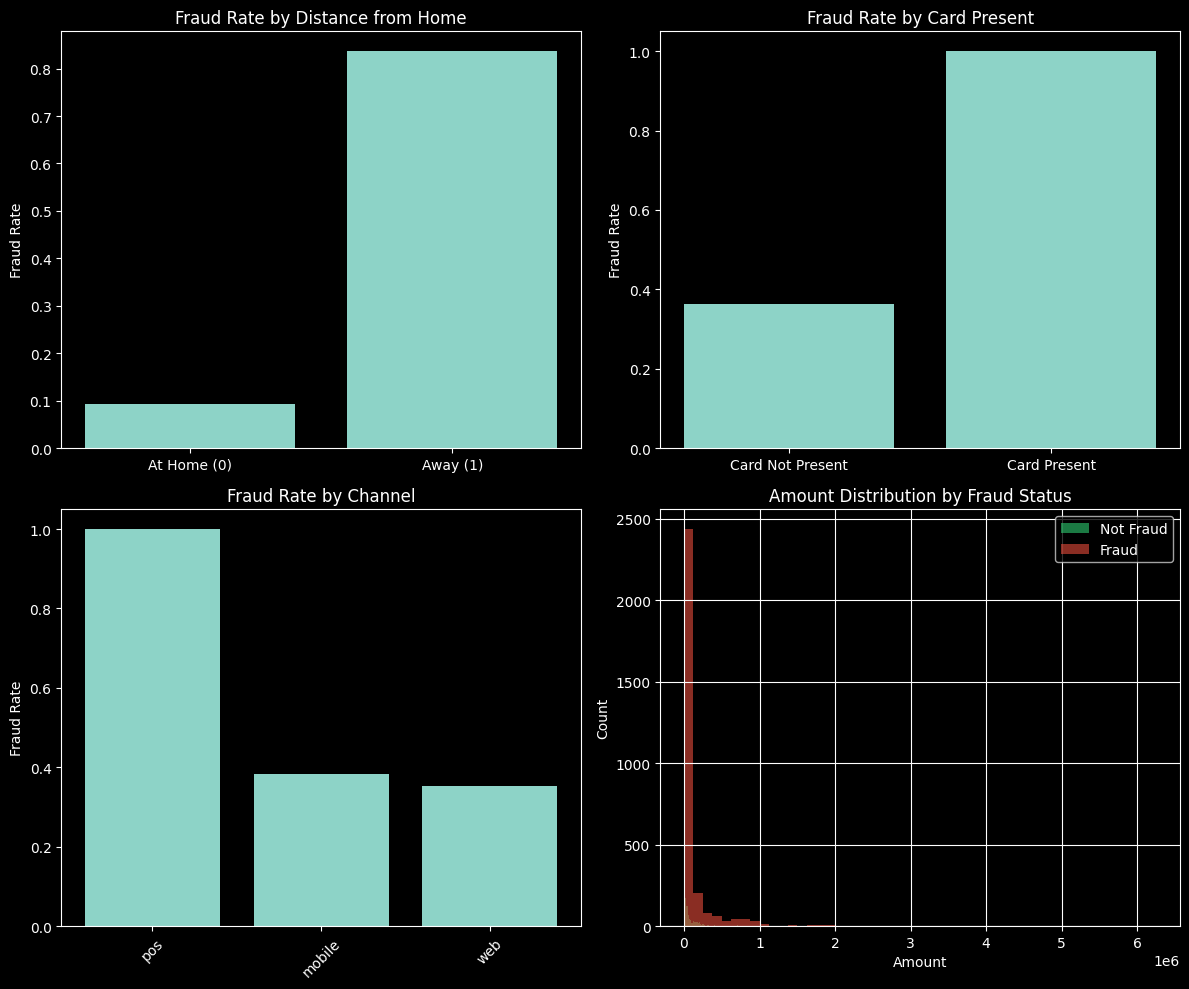

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

fraud_by_distance = df_eda.groupby("distance_from_home")["is_fraud"].mean()
axes[0, 0].bar(["At Home (0)", "Away (1)"], fraud_by_distance.values)
axes[0, 0].set_ylabel("Fraud Rate")
axes[0, 0].set_title("Fraud Rate by Distance from Home")

fraud_by_card = df_eda.groupby("card_present")["is_fraud"].mean()
axes[0, 1].bar(["Card Not Present", "Card Present"], fraud_by_card.values)
axes[0, 1].set_ylabel("Fraud Rate")
axes[0, 1].set_title("Fraud Rate by Card Present")

fraud_by_channel = df_eda.groupby("channel")["is_fraud"].mean().sort_values(ascending=False)
axes[1, 0].bar(fraud_by_channel.index, fraud_by_channel.values)
axes[1, 0].set_ylabel("Fraud Rate")
axes[1, 0].set_title("Fraud Rate by Channel")
axes[1, 0].tick_params(axis='x', rotation=45)

df_eda[df_eda["is_fraud"] == False]["amount"].hist(ax=axes[1, 1], bins=50, alpha=0.6, label="Not Fraud", color="#2ecc71")
df_eda[df_eda["is_fraud"] == True]["amount"].hist(ax=axes[1, 1], bins=50, alpha=0.6, label="Fraud", color="#e74c3c")
axes[1, 1].set_xlabel("Amount")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("Amount Distribution by Fraud Status")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

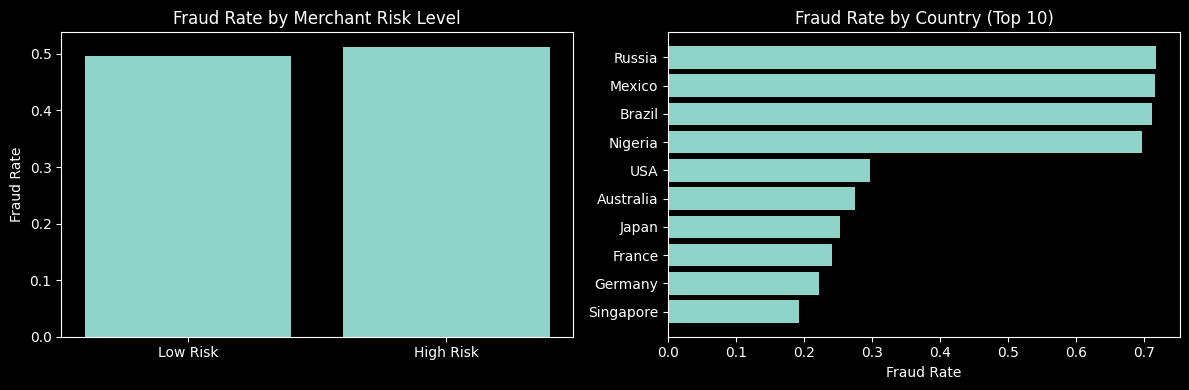

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fraud_by_risk = df_eda.groupby("high_risk_merchant")["is_fraud"].mean()
axes[0].bar(["Low Risk", "High Risk"], fraud_by_risk.values)
axes[0].set_ylabel("Fraud Rate")
axes[0].set_title("Fraud Rate by Merchant Risk Level")

fraud_by_country = df_eda.groupby("country")["is_fraud"].mean().sort_values(ascending=False).head(10)
axes[1].barh(fraud_by_country.index, fraud_by_country.values)
axes[1].set_xlabel("Fraud Rate")
axes[1].set_title("Fraud Rate by Country (Top 10)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

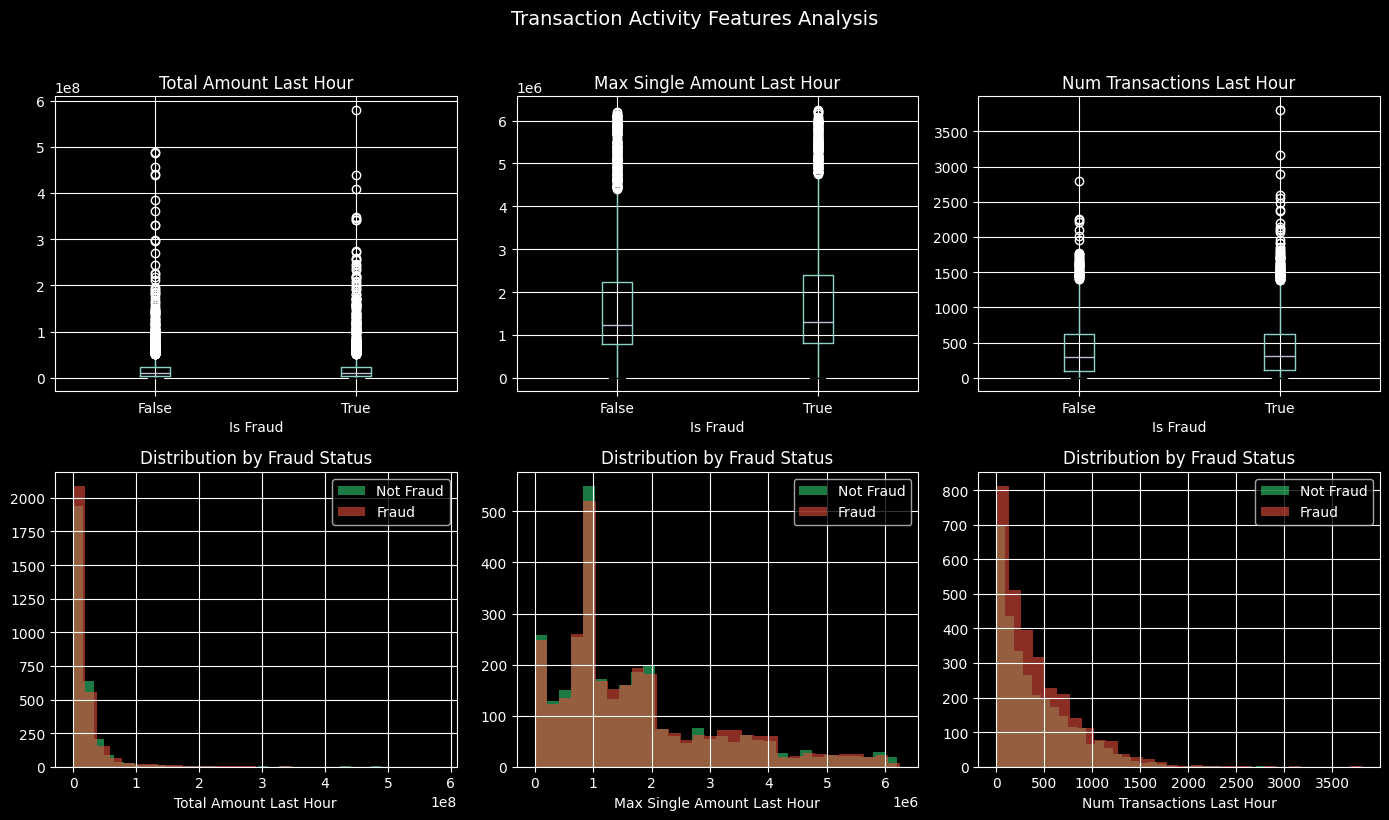

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

df_eda.boxplot(column="total_amount_last_hour", by="is_fraud", ax=axes[0, 0])
axes[0, 0].set_title("Total Amount Last Hour")
axes[0, 0].set_xlabel("Is Fraud")

df_eda.boxplot(column="max_single_amount_last_hour", by="is_fraud", ax=axes[0, 1])
axes[0, 1].set_title("Max Single Amount Last Hour")
axes[0, 1].set_xlabel("Is Fraud")

df_eda.boxplot(column="num_transac_last_hour", by="is_fraud", ax=axes[0, 2])
axes[0, 2].set_title("Num Transactions Last Hour")
axes[0, 2].set_xlabel("Is Fraud")

colors = {"Not Fraud": "#2ecc71", "Fraud": "#e74c3c"}
for fraud_val, label in [(False, "Not Fraud"), (True, "Fraud")]:
    subset = df_eda[df_eda["is_fraud"] == fraud_val]
    subset["total_amount_last_hour"].hist(ax=axes[1, 0], bins=30, alpha=0.6, label=label, color=colors[label])
    subset["max_single_amount_last_hour"].hist(ax=axes[1, 1], bins=30, alpha=0.6, label=label, color=colors[label])
    subset["num_transac_last_hour"].hist(ax=axes[1, 2], bins=30, alpha=0.6, label=label, color=colors[label])

axes[1, 0].set_xlabel("Total Amount Last Hour")
axes[1, 0].set_title("Distribution by Fraud Status")
axes[1, 0].legend()

axes[1, 1].set_xlabel("Max Single Amount Last Hour")
axes[1, 1].set_title("Distribution by Fraud Status")
axes[1, 1].legend()

axes[1, 2].set_xlabel("Num Transactions Last Hour")
axes[1, 2].set_title("Distribution by Fraud Status")
axes[1, 2].legend()

plt.suptitle("Transaction Activity Features Analysis", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

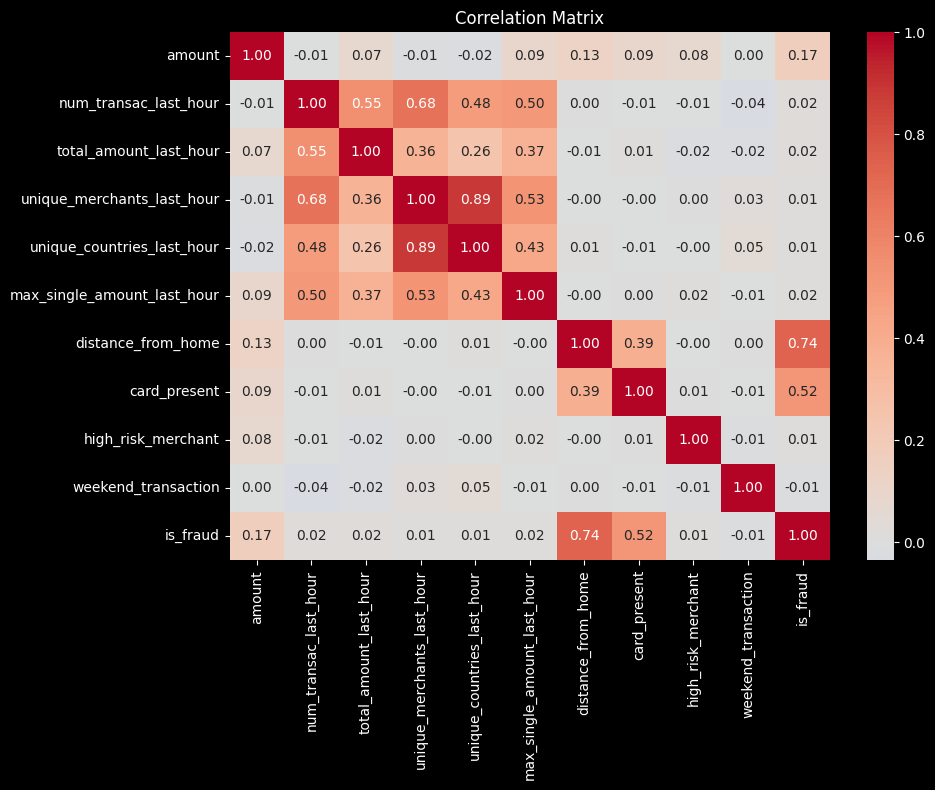

In [43]:
import seaborn as sns

# Select numeric columns for correlation
numeric_cols = [
    "amount",
    "num_transac_last_hour",
    "total_amount_last_hour",
    "unique_merchants_last_hour",
    "unique_countries_last_hour",
    "max_single_amount_last_hour",
    "distance_from_home",
    "card_present",
    "high_risk_merchant",
    "weekend_transaction",
    "is_fraud"
]

corr_matrix = df_eda[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Product Metrics

In [51]:
df_metrics = pd.read_csv(data_path, index_col=0)

usd_rates = {
    "USD": 1.0,
    "EUR": 1.08,
    "GBP": 1.27,
    "CAD": 0.72,
    "AUD": 0.65,
    "JPY": 0.0067,
    "BRL": 0.17,
    "RUB": 0.011,
    "NGN": 0.00061,
    "SGD": 0.74,
    "MXN": 0.058,
}

df_metrics["amount_usd"] = df_metrics.apply(
    lambda row: row["amount"] * usd_rates.get(row["currency"], 1.0), axis=1
)

total_transactions = len(df_metrics)
fraud_count = df_metrics["is_fraud"].sum()

# GMV in USD
gmv = df_metrics["amount_usd"].sum()

# AOV in USD
aov = df_metrics["amount_usd"].mean()

fraud_rate = fraud_count / total_transactions

# CoR - fraud losses / total volume in USD
fraud_amount = df_metrics.loc[df_metrics["is_fraud"] == True, "amount_usd"].sum()
cor = fraud_amount / gmv

print("=== Actual Data Metrics (USD) ===")
print(f"GMV (total volume):    ${gmv:,.2f}")
print(f"AOV (avg order value): ${aov:,.2f}")
print(f"Fraud Rate (Refund):   {fraud_rate:.2%}")
print(f"CoR (Cost of Risk):    {cor:.2%}")

=== Actual Data Metrics (USD) ===
GMV (total volume):    $4,098,998.74
AOV (avg order value): $683.17
Fraud Rate (Refund):   50.00%
CoR (Cost of Risk):    66.16%
